# EDA - Campaign features (Member 3)

**Features:** `contact`, `month`, `day_of_week`, `campaign`, `pdays`, `previous`, `poutcome`  |  **Target:** `y` (term deposit subscription)

These seven columns describe *how the bank contacted the client*, in this campaign and in earlier ones. All of them are known **before** the next call is made, so none of them leaks the outcome (unlike `duration`, which is dropped).

**Part 1** covers the four categorical features: `contact`, `poutcome`, `month`, `day_of_week`. **Part 2** covers the numeric features `campaign`, `pdays` and `previous`, and shows the `CampaignFeatures` transformer working on the real data.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2_contingency

# make `src` importable when the notebook runs from /notebooks
sys.path.append(str(Path.cwd().parent))
from src.config import RAW_DATA, TARGET, LEAKAGE_COLUMNS, ROOT
from src.data_cleaning import remove_duplicates, prepare_features_and_target

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUE, GREY, LIGHT = "#2a78d6", "#52514e", "#d9d8d2"     # bars / reference line / grid
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": LIGHT, "grid.linewidth": 0.6,
    "axes.grid.axis": "y",
})
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


def save_fig(name):
    """Save the current figure into results/figures with the eda_campaign_ prefix."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"eda_campaign_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load data and basic structure

In [2]:
raw = pd.read_csv(RAW_DATA, sep=";")
print("Raw shape:", raw.shape)
print("Exact duplicate rows (all columns, incl. duration):", raw.duplicated().sum())

Raw shape: (41188, 21)
Exact duplicate rows (all columns, incl. duration): 12


**Order matters when removing duplicates.** We use the shared helpers from `src/data_cleaning.py`: remove exact duplicates *first*, then drop `duration`. The next cell shows why - if `duration` were dropped first, many *different* calls would look identical and be deleted by mistake.

In [3]:
print("Duplicates found BEFORE dropping duration:", raw.duplicated().sum())
print("Duplicates found AFTER dropping duration :", raw.drop(columns=LEAKAGE_COLUMNS).duplicated().sum(),
      " <- these are different calls (different duration), not real duplicates")

clean = remove_duplicates(raw)
X, y = prepare_features_and_target(clean)            # drops the target and duration from the predictors
df = X.assign(y=(y == "yes").astype(int))            # y = 1 means the client subscribed

CAMPAIGN_COLS = ["contact", "month", "day_of_week", "campaign", "pdays", "previous", "poutcome"]
overall = df["y"].mean()
print(f"\nClean shape: {df.shape}   subscribers: {df['y'].sum():,}   overall subscription rate: {overall:.2%}")

Duplicates found BEFORE dropping duration: 12
Duplicates found AFTER dropping duration : 1784  <- these are different calls (different duration), not real duplicates

Clean shape: (41176, 20)   subscribers: 4,639   overall subscription rate: 11.27%


In [4]:
summary = pd.DataFrame({
    "dtype": df[CAMPAIGN_COLS].dtypes.astype(str),
    "unique values": df[CAMPAIGN_COLS].nunique(),
    "missing": df[CAMPAIGN_COLS].isna().sum(),
    "'unknown' coded": (df[CAMPAIGN_COLS] == "unknown").sum(),
})
summary

,dtype,unique values,missing,'unknown' coded
contact,object,2,0,0
month,object,10,0,0
day_of_week,object,5,0,0
campaign,int64,42,0,0
pdays,int64,27,0,0
previous,int64,8,0,0
poutcome,object,3,0,0


### Insight -> decision

- Finding: 41,176 clients remain after removing the **12** true duplicates (the same number as in our dataset proposal). The 7 campaign columns have **no missing values and no 'unknown' codes**.
- Decision: remove duplicates before dropping `duration`, using `remove_duplicates` from `src/data_cleaning.py`.
- Reason / alternative rejected: dropping `duration` first would delete 1,784 rows that are different calls, not duplicates.

## 2. Helpers

Every categorical feature gets the same treatment: a table of customers and subscription rate, and a bar chart with the overall rate (dashed line) as reference. The customer count is written under each category, so small groups are visible.

In [5]:
def rate_table(col, order=None):
    """Customers and subscription rate for each value of `col`."""
    t = df.groupby(col, observed=True)["y"].agg(customers="size", subscription_rate="mean")
    t["lift_vs_overall"] = t["subscription_rate"] / overall
    return t if order is None else t.loc[order]


def rate_bar(t, title, name, xlabel, figsize=(6.5, 4)):
    """Bar chart of subscription rate; dashed line = overall rate; n under each label."""
    fig, ax = plt.subplots(figsize=figsize)
    labels = [f"{i}\n(n={n:,})" for i, n in zip(t.index, t["customers"])]
    bars = ax.bar(labels, t["subscription_rate"] * 100, color=BLUE, width=0.6)
    ax.axhline(overall * 100, color=GREY, linestyle="--", linewidth=1.2, label=f"overall rate {overall:.1%}")
    ax.legend(loc="upper right", frameon=False)
    for b, r in zip(bars, t["subscription_rate"]):
        ax.annotate(f"{r:.1%}", (b.get_x() + b.get_width() / 2, b.get_height()), xytext=(0, 3),
                    textcoords="offset points", ha="center", va="bottom", fontsize=10, zorder=5,
                    bbox=dict(facecolor="white", edgecolor="none", pad=1))
    ax.set_ylabel("Subscription rate (%)")
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylim(0, t["subscription_rate"].max() * 100 * 1.3)
    save_fig(name)

## 3. `contact` - how the client was reached

In [6]:
t = rate_table("contact")
t

,customers,subscription_rate,lift_vs_overall
contact,,,
cellular,26135,0.147,1.308
telephone,15041,0.052,0.464


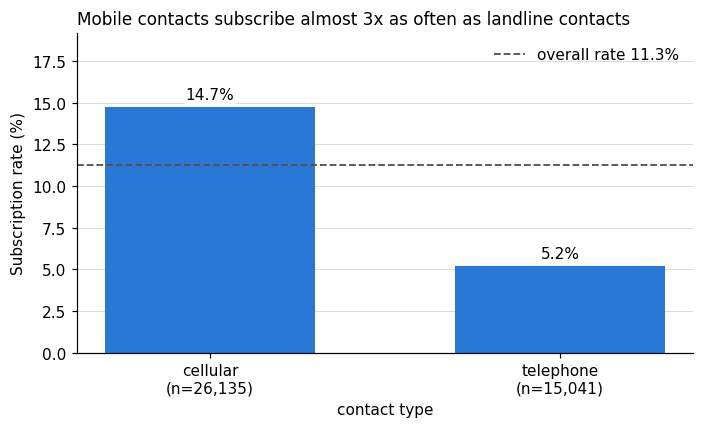

In [7]:
rate_bar(t, "Mobile contacts subscribe almost 3x as often as landline contacts", "contact_rate", "contact type")

The next cell checks whether `contact` could be hiding something else. The file is ordered by date, so we split the rows into five equal blocks (oldest to newest) and look at the share of mobile contacts and the overall subscription rate in each.

In [8]:
block = pd.cut(np.arange(len(df)), 5, labels=["1st (oldest)", "2nd", "3rd", "4th", "5th (newest)"])
by_block = df.groupby(block, observed=True)
pd.DataFrame({
    "share cellular": by_block["contact"].apply(lambda s: (s == "cellular").mean()),
    "overall subscription rate": by_block["y"].mean(),
})

,share cellular,overall subscription rate
1st (oldest),0.000,0.031
2nd,0.447,0.054
3rd,0.919,0.059
4th,0.928,0.111
5th (newest),0.880,0.308


### Insight -> decision

- Finding: **cellular 14.7%** (26,135 clients) vs **telephone 5.2%** (15,041 clients), about 2.8 times higher. In the oldest fifth of the file *every* call was to a landline, so contact type and time period are mixed together.
- Decision: keep `contact` and one-hot encode it (2 categories, no missing values).
- Reason / caution: the gap is large, but part of it may be a time effect (mobile numbers were used later in the file, and the overall subscription rate also rises from block to block). We describe it as a strong pattern, not proof that mobile numbers cause subscriptions.

## 4. `poutcome` - result of the previous campaign

In [9]:
t = rate_table("poutcome", order=["success", "failure", "nonexistent"])
t

,customers,subscription_rate,lift_vs_overall
poutcome,,,
success,1373,0.651,5.779
failure,4252,0.142,1.263
nonexistent,35551,0.088,0.784


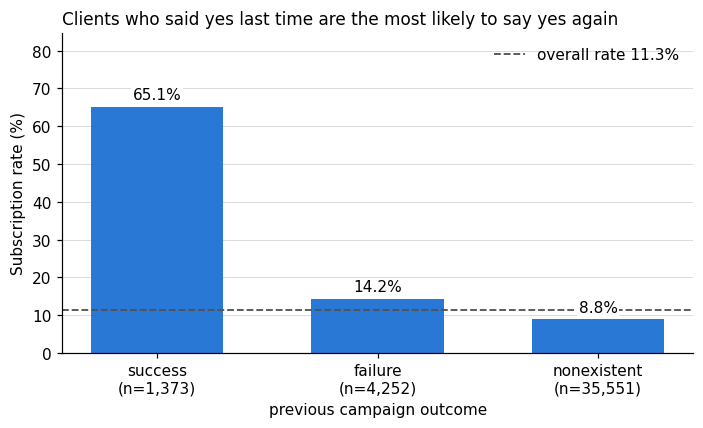

In [10]:
rate_bar(t, "Clients who said yes last time are the most likely to say yes again", "poutcome_rate", "previous campaign outcome")

### Insight -> decision

- Finding: **success 65.1%**, failure 14.2%, nonexistent (never contacted before) 8.8%. A previous success is about **5.8 times** the overall rate of 11.3% - the strongest single signal in our feature group. But only 1,373 clients (3.3%) are previous successes, so it is a strong signal on a narrow group.
- Decision: keep `poutcome` and one-hot encode it.
- Reason: strongest predictor, three clear categories, no missing values.

## 5. `month` - month of the last contact

In [11]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]   # calendar order (no jan/feb in the data)
t = rate_table("month", order=month_order)
t["share_of_all_calls"] = t["customers"] / len(df)
t

,customers,subscription_rate,lift_vs_overall,share_of_all_calls
month,,,,
mar,546,0.505,4.487,0.013
apr,2631,0.205,1.818,0.064
may,13767,0.064,0.571,0.334
jun,5318,0.105,0.933,0.129
jul,7169,0.090,0.802,0.174
aug,6176,0.106,0.941,0.150
sep,570,0.449,3.986,0.014
oct,717,0.439,3.900,0.017
nov,4100,0.101,0.901,0.100


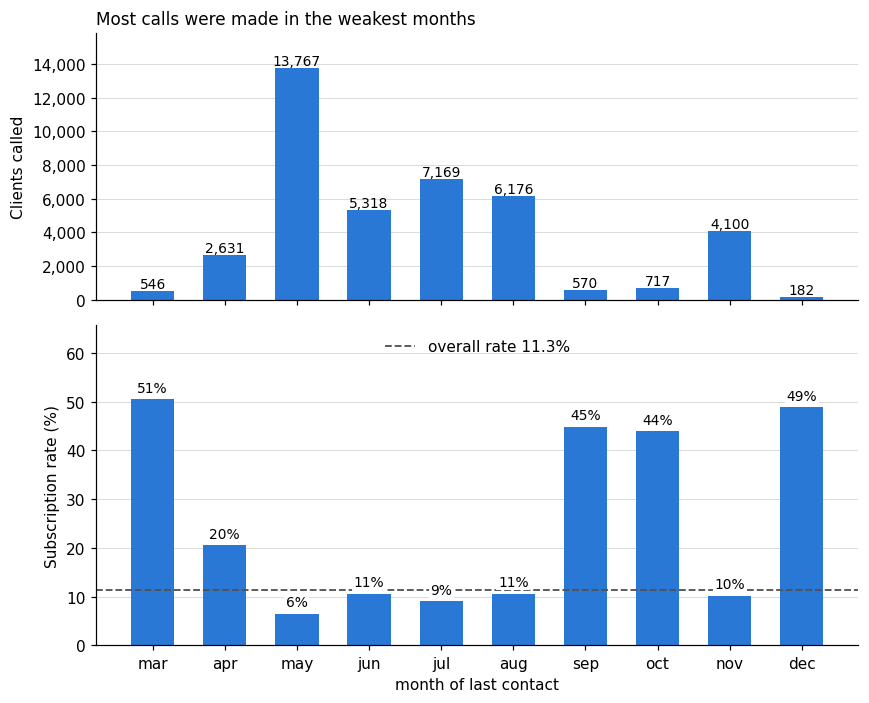

In [12]:
# Two panels with the same x-axis (volume on top, rate below) instead of one chart with two y-axes.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True, gridspec_kw={"height_ratios": [1, 1.2]})

ax1.bar(t.index, t["customers"], color=BLUE, width=0.6)
for x, n in zip(t.index, t["customers"]):
    ax1.text(x, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("Clients called")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.set_ylim(0, t["customers"].max() * 1.15)
ax1.set_title("Most calls were made in the weakest months", loc="left", fontsize=11)

ax2.bar(t.index, t["subscription_rate"] * 100, color=BLUE, width=0.6)
ax2.axhline(overall * 100, color=GREY, linestyle="--", linewidth=1.2, label=f"overall rate {overall:.1%}")
ax2.legend(loc="upper center", frameon=False)
for x, r in zip(t.index, t["subscription_rate"]):
    ax2.annotate(f"{r:.0%}", (x, r * 100), xytext=(0, 3), textcoords="offset points", ha="center",
                 va="bottom", fontsize=9, zorder=5, bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax2.set_ylabel("Subscription rate (%)")
ax2.set_xlabel("month of last contact")
ax2.set_ylim(0, t["subscription_rate"].max() * 100 * 1.3)
save_fig("month_volume_and_rate")

### Insight -> decision

- Finding: **May holds one third of all calls (33.4%) and has the lowest rate (6.4%)**. March, September, October and December convert at **44-51%**, but together they are only 2,015 calls (4.9%). April is in between (20.5%). There is no January or February in the data.
- Decision: keep `month` and one-hot encode it.
- Reason / caution: the differences are large, so the model should use them. The small months may reflect *who* was called then (for example, follow-ups of earlier successes), so this is a pattern worth testing in a future campaign, not proof that March itself causes subscriptions. `month` is also a partial stand-in for time, which matters for the chronological test split.

## 6. `day_of_week` - weekday of the last contact

In [13]:
t = rate_table("day_of_week", order=["mon", "tue", "wed", "thu", "fri"])
t

,customers,subscription_rate,lift_vs_overall
day_of_week,,,
mon,8512,0.100,0.883
tue,8086,0.118,1.046
wed,8134,0.117,1.036
thu,8618,0.121,1.075
fri,7826,0.108,0.960


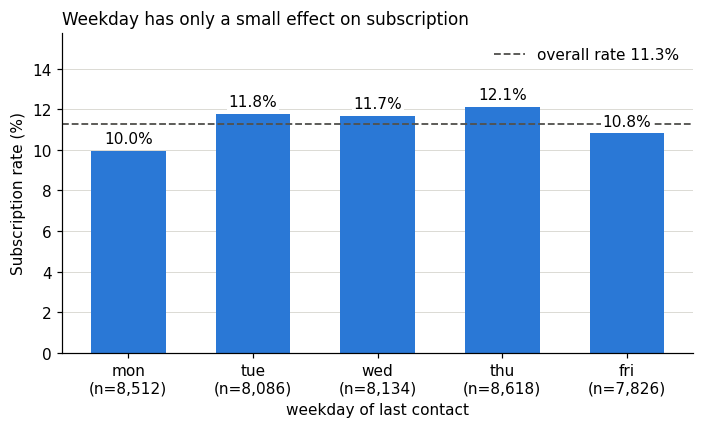

In [14]:
rate_bar(t, "Weekday has only a small effect on subscription", "day_of_week_rate", "weekday of last contact")

### Insight -> decision

- Finding: rates range only from **10.0% (Monday) to 12.1% (Thursday)** - about 2 percentage points, with 7,800-8,600 clients on each day.
- Decision: keep `day_of_week` for now (cheap to encode); Member 4's feature-selection step can test dropping it.
- Reason: a weak feature is still a useful result. It tells the bank that the calling day matters much less than contact type, month or customer history.

## 7. How strong is each feature? (chi-square and Cramer's V)

A chi-square test asks whether a feature and `y` are independent. With 41,000 rows even tiny differences are "significant", so the p-value alone is not enough. **Cramer's V** (0 = no link, 1 = perfect link) shows the *strength* of the link.

In [15]:
def cramers_v(col):
    ct = pd.crosstab(df[col], df["y"])
    chi2, p, _, _ = chi2_contingency(ct)
    return pd.Series({"chi2": chi2, "p_value": p, "cramers_v": np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))})

strength = pd.DataFrame({c: cramers_v(c) for c in ["poutcome", "month", "contact", "day_of_week"]}).T
strength.sort_values("cramers_v", ascending=False)

,chi2,p_value,cramers_v
poutcome,"4,230.143",0.000,0.321
month,"3,103.033",0.000,0.275
contact,862.081,0.000,0.145
day_of_week,26.054,0.000,0.025


### Insight -> decision

- Finding: strength of link with `y` (Cramer's V): **`poutcome` 0.32 > `month` 0.28 > `contact` 0.15 >> `day_of_week` 0.025**. All four p-values are below 0.001, but for `day_of_week` that only reflects the large sample - the effect itself is negligible.
- Decision: `poutcome`, `month` and `contact` are the key categorical signals in this group; `day_of_week` is the first candidate to drop in feature selection.
- Reason: this ranking agrees with the bar charts above, so the numbers and the pictures tell the same story.

### Part 1 summary

| Feature | Subscription pattern | Decision |
|---|---|---|
| `poutcome` | success 65.1% vs 8.8% never contacted | keep, one-hot encode |
| `month` | 6.4% (May) to 50.5% (March) | keep, one-hot encode |
| `contact` | cellular 14.7% vs telephone 5.2% | keep, one-hot encode |
| `day_of_week` | 10.0% to 12.1% | keep for now; Member 4 may drop it |

---
# Part 2 - numeric features: `campaign`, `pdays`, `previous`

## 8. `campaign` - contacts made to this client in this campaign

In [16]:
print("Minimum:", df["campaign"].min(), "(the count includes the last contact, so it starts at 1)")
q1, q3 = df["campaign"].quantile([0.25, 0.75])
iqr_fence = q3 + 1.5 * (q3 - q1)
p99 = df["campaign"].quantile(0.99)
pd.DataFrame({
    "value": [df["campaign"].median(), q3, df["campaign"].quantile(0.95), p99, df["campaign"].max(), iqr_fence],
    "clients above it": [(df["campaign"] > df["campaign"].median()).sum(), (df["campaign"] > q3).sum(),
                         (df["campaign"] > df["campaign"].quantile(0.95)).sum(), (df["campaign"] > p99).sum(),
                         0, (df["campaign"] > iqr_fence).sum()],
}, index=["median", "75th percentile", "95th percentile", "99th percentile", "maximum", "IQR upper fence (Q3 + 1.5 x IQR)"])

Minimum: 1 (the count includes the last contact, so it starts at 1)


,value,clients above it
median,2.000,12974
75th percentile,3.000,7634
95th percentile,7.000,1777
99th percentile,14.000,406
maximum,56.000,0
IQR upper fence (Q3 + 1.5 x IQR),6.000,2406


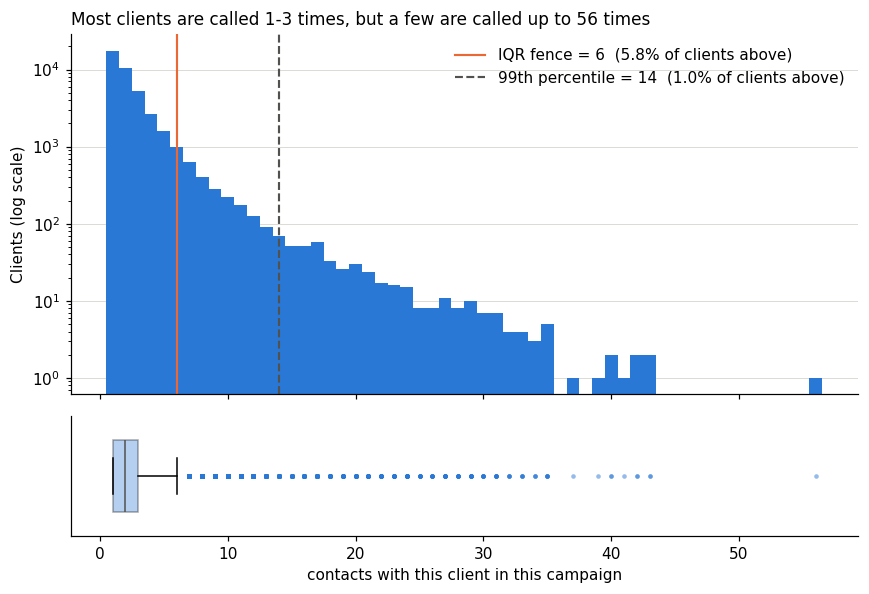

In [17]:
ORANGE = "#eb6834"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.hist(df["campaign"], bins=np.arange(0.5, df["campaign"].max() + 1.5, 1), color=BLUE)
ax1.set_yscale("log")
ax1.axvline(iqr_fence, color=ORANGE, linewidth=1.4, label=f"IQR fence = {iqr_fence:.0f}  ({(df['campaign'] > iqr_fence).mean():.1%} of clients above)")
ax1.axvline(p99, color=GREY, linestyle="--", linewidth=1.4, label=f"99th percentile = {p99:.0f}  ({(df['campaign'] > p99).mean():.1%} of clients above)")
ax1.legend(frameon=False, loc="upper right")
ax1.set_ylabel("Clients (log scale)")
ax1.set_title("Most clients are called 1-3 times, but a few are called up to 56 times", loc="left", fontsize=11)

ax2.boxplot(df["campaign"], vert=False, widths=0.6, patch_artist=True, boxprops=dict(facecolor=BLUE, alpha=0.35),
            medianprops=dict(color=GREY), flierprops=dict(marker="o", markersize=3, markerfacecolor=BLUE, markeredgecolor="none", alpha=0.5))
ax2.set_yticks([])
ax2.set_xlabel("contacts with this client in this campaign")
ax2.grid(axis="y", visible=False)
save_fig("campaign_distribution")

The distribution is heavily right-skewed. Two ways to decide where an "outlier" starts are drawn above: the **IQR rule** (orange) and the **99th percentile** (dashed grey). The IQR fence sits at 6, which would treat almost 6% of clients as outliers - but 6, 7 or 8 calls to one client is ordinary in a telemarketing campaign. The 99th percentile only touches the extreme tail.

In [18]:
call_bins = pd.cut(df["campaign"], [0, 1, 2, 3, 5, 10, 100], labels=["1", "2", "3", "4-5", "6-10", "11+"])
t = df.groupby(call_bins, observed=True)["y"].agg(customers="size", subscription_rate="mean")
t

,customers,subscription_rate
campaign,,
1,17634,0.130
2,10568,0.115
3,5340,0.107
4-5,4249,0.087
6-10,2516,0.063
11+,869,0.031


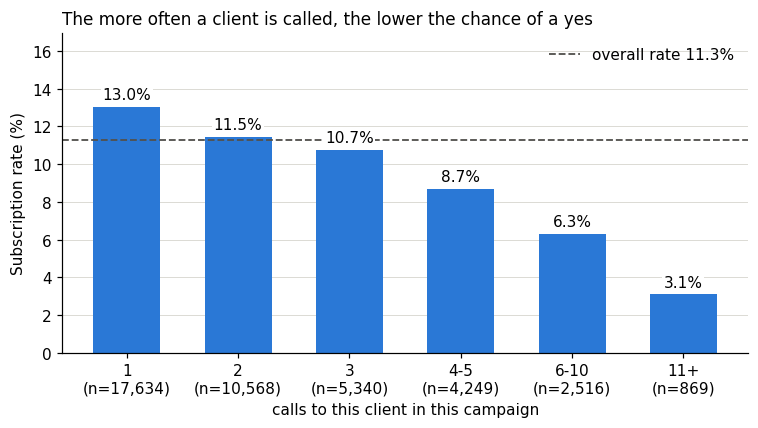

In [19]:
rate_bar(t, "The more often a client is called, the lower the chance of a yes", "campaign_rate", "calls to this client in this campaign", figsize=(7, 4))

### Insight -> decision

- Finding: median 2, 75th percentile 3, 99th percentile 14, maximum 56. The subscription rate falls steadily with the number of calls: **13.0% after one call, 6.3% for 6-10 calls and 3.1% for 11 or more**.
- Decision: **cap `campaign` at the 99th percentile** (14), learned on the training data only. Do not remove any rows.
- Reason / alternative rejected: values up to 56 are real clients, so deleting them would lose data and bias the model. The IQR rule (fence = 6) would change about 6% of the clients, many of them ordinary. Capping at the 99th percentile changes only about 1% and limits the influence of the extremes, which matters most for scale-sensitive models. Tree models are not affected by extreme values as much, but all four models must be compared on the same features.

## 9. `pdays` and `previous` - earlier contact

`pdays` is the number of days since the client was last contacted in an *earlier* campaign, and `previous` is the number of contacts before this campaign. The documentation says `pdays = 999` means "not previously contacted". Let us check that against `poutcome`.

In [20]:
pd.crosstab(df["pdays"] == 999, df["poutcome"], margins=True).rename(index={True: "pdays = 999", False: "pdays = a real value"})

poutcome,failure,nonexistent,success,All
pdays,,,,
pdays = a real value,142,0,1373,1515
pdays = 999,4110,35551,0,39661
All,4252,35551,1373,41176


**The documentation is not fully consistent with the data.** 4,110 clients have `pdays = 999` but a previous outcome of *failure* - so they *were* contacted before, and the number of days was simply not recorded. That means `pdays = 999` cannot be used on its own to decide whether someone was contacted before.

The next cell tests the alternative: `previous > 0`.

In [21]:
print("previous > 0 is identical to poutcome != 'nonexistent':", ((df["previous"] > 0) == (df["poutcome"] != "nonexistent")).all())
print("clients with a recorded pdays (not 999):", (df["pdays"] != 999).sum(), "| share of pdays = 999:", f"{(df['pdays'] == 999).mean():.1%}")
print("recorded pdays values ->", df.loc[df["pdays"] != 999, "pdays"].describe().round(1).to_dict())

previous > 0 is identical to poutcome != 'nonexistent': True
clients with a recorded pdays (not 999): 1515 | share of pdays = 999: 96.3%
recorded pdays values -> {'count': 1515.0, 'mean': 6.0, 'std': 3.8, 'min': 0.0, '25%': 3.0, '50%': 6.0, '75%': 7.0, 'max': 27.0}


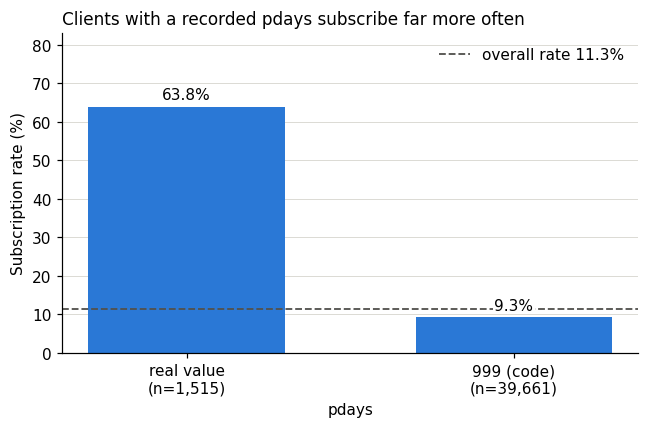

In [22]:
known = df["pdays"] != 999
t = pd.DataFrame({"customers": [known.sum(), (~known).sum()],
                  "subscription_rate": [df.loc[known, "y"].mean(), df.loc[~known, "y"].mean()]},
                 index=["real value", "999 (code)"])
rate_bar(t, "Clients with a recorded pdays subscribe far more often", "pdays_known_rate", "pdays", figsize=(6, 4))

In [23]:
prev_groups = df["previous"].clip(upper=4).map(lambda v: "4+" if v >= 4 else str(v))
t = df.groupby(prev_groups)["y"].agg(customers="size", subscription_rate="mean")
t

,customers,subscription_rate
previous,,
0,35551,0.088
1,4561,0.212
2,754,0.464
3,216,0.593
4+,94,0.574


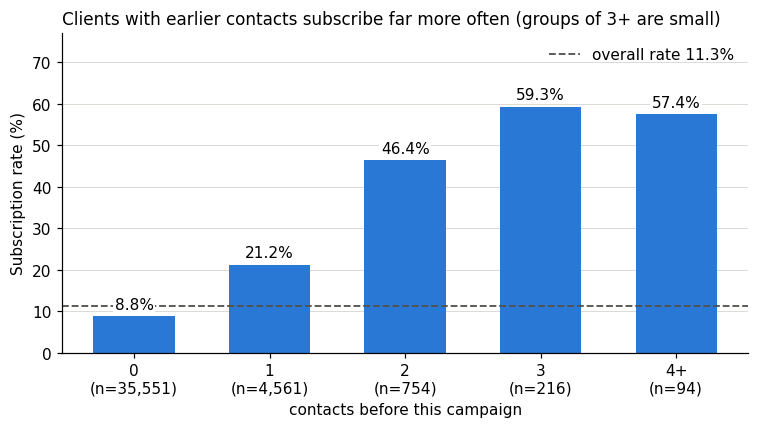

In [24]:
rate_bar(t, "Clients with earlier contacts subscribe far more often (groups of 3+ are small)", "previous_rate", "contacts before this campaign", figsize=(7, 4))

### Insight -> decision

- Finding: **96.3% of rows have `pdays = 999`**. The documentation says this means "never contacted", but 4,110 of those clients have `poutcome = failure`. By contrast, `previous > 0` matches `poutcome` exactly (35,551 clients have both `previous = 0` and `poutcome = nonexistent`). Clients with a recorded `pdays` subscribe at **63.8%** vs **9.3%** for 999. `previous` raises the rate quickly: 8.8% at 0, 21.2% at 1, 46.4% at 2, 59.3% at 3, then it levels off (57.4% for 4+). The groups with 3 or more earlier contacts are small (216, and 94 for 4+), so their rates are less reliable.
- Decision: create **`previously_contacted`** (`previous > 0`) and **`pdays_known`** (`pdays != 999`); recode `pdays = 999` to **-1**. Keep `previous` as a number.
- Reason / alternative rejected: using `pdays == 999` as "never contacted" (as in the documentation) would mislabel 4,110 clients. The value 999 is a code, not 999 days: left as a number it would look like a very long gap and distort scaling and distance-based models. -1 lets trees split cleanly between "no recorded gap" and real gaps of 0-27 days.

## 10. Correlation with the target

In [25]:
from src.features import CampaignFeatures

eng = CampaignFeatures().fit_transform(df[["campaign", "pdays", "previous"]])   # EDA only: fitted on all rows here
corr = pd.DataFrame({
    "as in the raw data": [df["campaign"].corr(df["y"]), df["pdays"].corr(df["y"]), df["previous"].corr(df["y"]), np.nan, np.nan],
    "after CampaignFeatures": [eng["campaign"].corr(df["y"]), eng["pdays"].corr(df["y"]), eng["previous"].corr(df["y"]),
                               eng["previously_contacted"].corr(df["y"]), eng["pdays_known"].corr(df["y"])],
}, index=["campaign", "pdays", "previous", "previously_contacted (new)", "pdays_known (new)"])
corr

,as in the raw data,after CampaignFeatures
campaign,-0.066,-0.070
pdays,-0.325,0.279
previous,0.230,0.230
previously_contacted (new),NaN,0.194
pdays_known (new),NaN,0.325


### Insight -> decision

- Finding: `campaign` has a weak negative link with `y`. Raw `pdays` shows a fairly strong negative correlation, but only because the code 999 is treated as a huge number - so that number reflects the code, not real days. After recoding to -1 it flips to a positive value (+0.28), and that value mostly reflects "-1 vs a real number of days", not the length of the gap. `previous`, `previously_contacted` and `pdays_known` all show a positive link.
- Decision: use the recoded `pdays` together with the two flags.
- Reason: a correlation on the raw `pdays` would be misleading; this is another reason to treat 999 as a code. Pearson correlation only measures straight-line links, so the bar charts above remain the main evidence for non-linear patterns such as the fall in rate with `campaign`.

## 11. `CampaignFeatures` on the real data

This is the transformer from `src/features.py` (see `tests/test_features.py`). Here it is fitted on all rows only to *look* at its effect; in modelling it is the first step of the pipeline and is fitted on the **training rows of each fold only**, so the cap never uses test information.

In [26]:
tf = CampaignFeatures(cap_quantile=0.99).fit(df[["campaign", "pdays", "previous"]])
out = tf.transform(df[["campaign", "pdays", "previous"]])
print(f"campaign cap learned in fit(): {tf.campaign_cap_:.0f}")
print(f"rows changed by the cap: {(df['campaign'] > tf.campaign_cap_).sum()} of {len(df):,} ({(df['campaign'] > tf.campaign_cap_).mean():.1%})   |   rows removed: {len(df) - len(out)}")
print(f"pdays 999 recoded to -1: {(out['pdays'] == -1).sum():,}   |   previously_contacted = 1: {out['previously_contacted'].sum():,}   |   pdays_known = 1: {out['pdays_known'].sum():,}")
pd.concat({"before": df[["campaign", "pdays", "previous"]].describe().T[["min", "50%", "max"]],
           "after": out[["campaign", "pdays", "previous"]].describe().T[["min", "50%", "max"]]}, axis=1)

campaign cap learned in fit(): 14
rows changed by the cap: 406 of 41,176 (1.0%)   |   rows removed: 0
pdays 999 recoded to -1: 39,661   |   previously_contacted = 1: 5,625   |   pdays_known = 1: 1,515


before                  after              
            min     50%     max    min    50%    max
campaign  1.000   2.000  56.000  1.000  2.000 14.000
pdays     0.000 999.000 999.000 -1.000 -1.000 27.000
previous  0.000   0.000   7.000  0.000  0.000  7.000

### Insight -> decision

- Finding: the transformer changes only what the EDA said needs changing: about 1% of `campaign` values (capped at 14), every `pdays = 999` (recoded to -1), and it adds two flag columns. No row is removed.
- Decision: use `CampaignFeatures` as the first step of every model's pipeline, so all four models are compared on the same features and the backend applies exactly the same logic at prediction time.